In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
#from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor

## Data Collection & Preprocessing


In [ ]:
car=pd.read_csv('/content/quikr_car.csv')

In [ ]:
car.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [ ]:
car.shape

(892, 6)

In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [ ]:
car.isnull().sum()

,0
name,0
company,0
year,0
Price,0
kms_driven,52
fuel_type,55


In [ ]:
car=car[car['year'].str.isnumeric()]

In [ ]:
car['year']=car['year'].astype(int)

In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 842 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        842 non-null    object
 1   company     842 non-null    object
 2   year        842 non-null    int64 
 3   Price       842 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: int64(1), object(5)
memory usage: 46.0+ KB


In [ ]:
car.isnull().sum()

,0
name,0
company,0
year,0
Price,0
kms_driven,2
fuel_type,5


In [ ]:
car['Price']

,Price
0,"80,000"
1,"4,25,000"
2,Ask For Price
3,"3,25,000"
4,"5,75,000"
...,...
886,"3,00,000"
888,"2,60,000"
889,"3,90,000"
890,"1,80,000"


In [ ]:
car=car[car['Price']!='Ask For Price']

In [ ]:
car['Price'] = car['Price'].astype(str).str.replace(',','')
car['Price'] = car['Price'].str.replace(' ','').astype(int)

In [ ]:
car['Price']

,Price
0,80000
1,425000
3,325000
4,575000
6,175000
...,...
886,300000
888,260000
889,390000
890,180000


In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 819 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        819 non-null    object
 1   company     819 non-null    object
 2   year        819 non-null    int64 
 3   Price       819 non-null    int64 
 4   kms_driven  819 non-null    object
 5   fuel_type   816 non-null    object
dtypes: int64(2), object(4)
memory usage: 44.8+ KB


In [ ]:
car['kms_driven']=car['kms_driven'].str.split(' ').str.get(0).str.replace(',','')

In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 819 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        819 non-null    object
 1   company     819 non-null    object
 2   year        819 non-null    int64 
 3   Price       819 non-null    int64 
 4   kms_driven  819 non-null    object
 5   fuel_type   816 non-null    object
dtypes: int64(2), object(4)
memory usage: 44.8+ KB


In [ ]:
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
6,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
886,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
888,Tata Zest XM Diesel,Tata,2018,260000,27000,Diesel
889,Mahindra Quanto C8,Mahindra,2013,390000,40000,Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,180000,Petrol,NaN


In [ ]:
car=car[car['kms_driven'].str.isnumeric()]

In [ ]:
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
6,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
883,Maruti Suzuki Ritz VXI ABS,Maruti,2011,270000,50000,Petrol
885,Tata Indica V2 DLE BS III,Tata,2009,110000,30000,Diesel
886,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
888,Tata Zest XM Diesel,Tata,2018,260000,27000,Diesel


In [ ]:
car['kms_driven']=car['kms_driven'].astype(int)

/tmp/ipython-input-1713770885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car['kms_driven']=car['kms_driven'].astype(int)


In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 817 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        817 non-null    object
 1   company     817 non-null    object
 2   year        817 non-null    int64 
 3   Price       817 non-null    int64 
 4   kms_driven  817 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.7+ KB


In [ ]:
car=car[~car['fuel_type'].isna()]

In [ ]:
car['name']=car['name'].str.split(' ').str.slice(0,3).str.join(' ')

/tmp/ipython-input-3677590539.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car['name']=car['name'].str.split(' ').str.slice(0,3).str.join(' ')


In [ ]:
car['name']

,name
0,Hyundai Santro Xing
1,Mahindra Jeep CL550
3,Hyundai Grand i10
4,Ford EcoSport Titanium
6,Ford Figo
...,...
883,Maruti Suzuki Ritz
885,Tata Indica V2
886,Toyota Corolla Altis
888,Tata Zest XM


In [ ]:
car=car.reset_index(drop=True)

In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 38.4+ KB


In [ ]:
car.describe()

,year,Price,kms_driven
count,816.000000,8.160000e+02,816.000000
mean,2012.444853,4.117176e+05,46275.531863
std,4.002992,4.751844e+05,34297.428044
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.750000e+05,27000.000000
50%,2013.000000,2.999990e+05,41000.000000
75%,2015.000000,4.912500e+05,56818.500000
max,2019.000000,8.500003e+06,400000.000000


In [ ]:
car=car[car['Price']<6e6].reset_index(drop=True)

In [ ]:
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
810,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol
811,Tata Indica V2,Tata,2009,110000,30000,Diesel
812,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
813,Tata Zest XM,Tata,2018,260000,27000,Diesel


In [ ]:
#print(car.fuel_type.value_counts())
#print(car.company.value_counts())
#print(car.year.value_counts())

In [ ]:
#car.replace({'fuel_type' : {'Petrol':0, 'Diesel':1, 'CNG':2}},inplace=True)

In [ ]:
car.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel


In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        815 non-null    object
 1   company     815 non-null    object
 2   year        815 non-null    int64 
 3   Price       815 non-null    int64 
 4   kms_driven  815 non-null    int64 
 5   fuel_type   815 non-null    object
dtypes: int64(3), object(3)
memory usage: 38.3+ KB


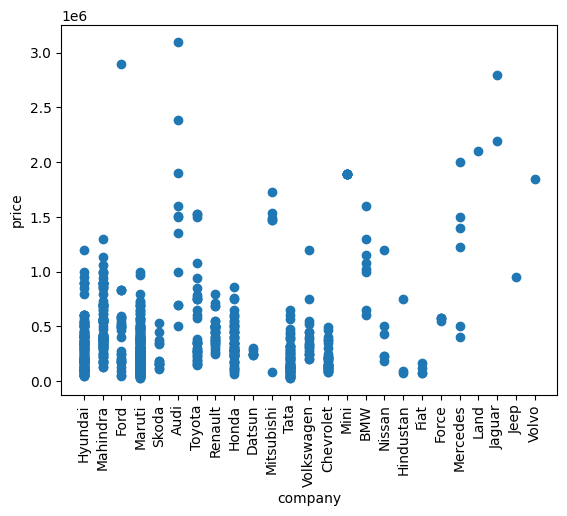

In [ ]:
plt.xlabel('company')
plt.ylabel('price')
plt.scatter(car['company'], car['Price'])
plt.xticks(rotation=90)

plt.show()

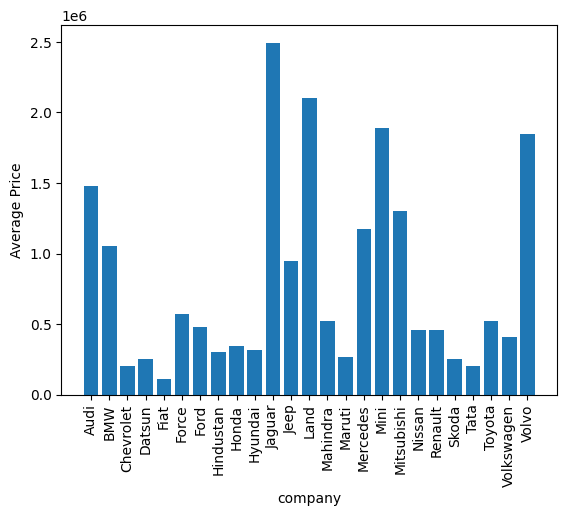

In [ ]:
# Calculate the average price for each company
company_prices = car.groupby('company')['Price'].mean()

# Create the bar graph
plt.bar(company_prices.index, company_prices.values)

plt.xlabel('company')  # Keep the original x-axis label
plt.ylabel('Average Price')  # Update y-axis label for clarity
plt.xticks(rotation=90)  # Keep the x-axis label rotation

plt.show()

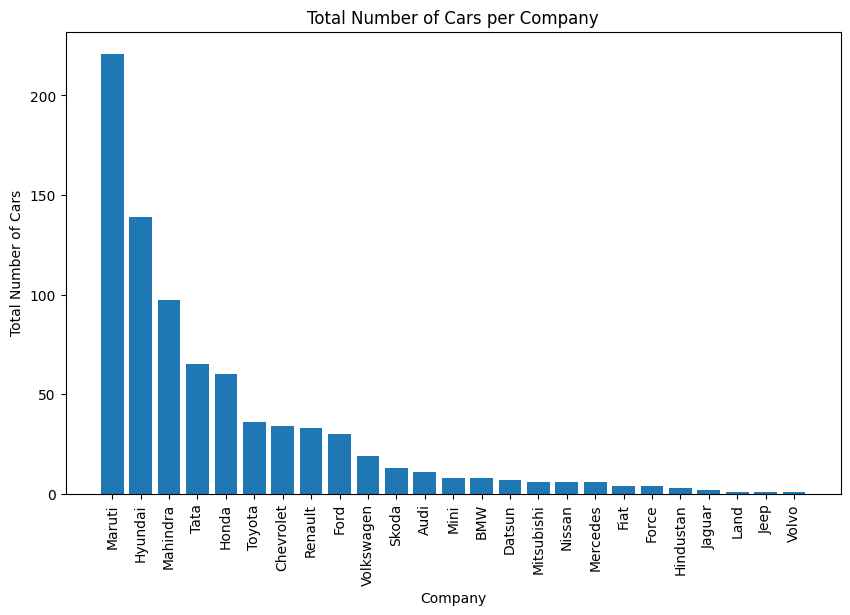

In [ ]:
# Calculate the counts of cars for each company
company_counts = car['company'].value_counts()

# Create the bar graph
plt.figure(figsize=(10, 6))  # Adjust figure size for better readability
plt.bar(company_counts.index, company_counts.values)
plt.xlabel('Company')
plt.ylabel('Total Number of Cars')
plt.title('Total Number of Cars per Company')
plt.xticks(rotation=90)
plt.show()

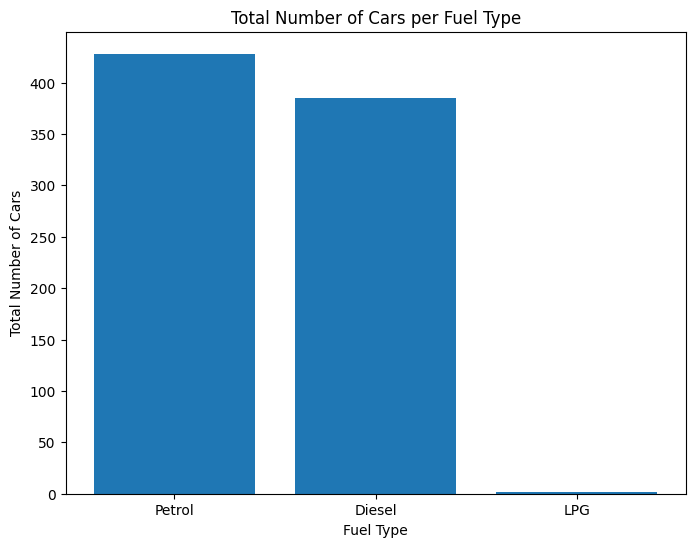

In [ ]:
# Calculate the counts of cars for each fuel type
fuel_type_counts = car['fuel_type'].value_counts()

# Create the bar graph
plt.figure(figsize=(8, 6))  # Adjust figure size for better readability
plt.bar(fuel_type_counts.index, fuel_type_counts.values)
plt.xlabel('Fuel Type')
plt.ylabel('Total Number of Cars')
plt.title('Total Number of Cars per Fuel Type')
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.show()

KeyError: 'price'

In [ ]:
car.to_csv('Cleaned_Car_data.csv')

In [ ]:
car = pd.read_csv("Cleaned_Car_data.csv")

X_car = car[['name','company','year','kms_driven','fuel_type']]
y_car = car['price']

car_pipe = Pipeline([
    ('pre', ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['name','company','fuel_type'])
    ], remainder='passthrough')),
    ('model', RandomForestRegressor())
])

car_pipe.fit(X_car, y_car)
pickle.dump(car_pipe, open("car_model.pkl", "wb"))

KeyError: 'price'

In [ ]:
car_df = pd.read_csv("Cleaned_Car_data.csv")
car_df = car_df.drop(columns=['Unnamed: 0'], errors='ignore')


# Splitting the data into targeting data


In [ ]:
X=car.drop(columns='Price')
Y=car['Price']

In [ ]:
print(X)
print(Y)

                       name   company  year  kms_driven fuel_type
0       Hyundai Santro Xing   Hyundai  2007       45000    Petrol
1       Mahindra Jeep CL550  Mahindra  2006          40    Diesel
2         Hyundai Grand i10   Hyundai  2014       28000    Petrol
3    Ford EcoSport Titanium      Ford  2014       36000    Diesel
4                 Ford Figo      Ford  2012       41000    Diesel
..                      ...       ...   ...         ...       ...
810      Maruti Suzuki Ritz    Maruti  2011       50000    Petrol
811          Tata Indica V2      Tata  2009       30000    Diesel
812    Toyota Corolla Altis    Toyota  2009      132000    Petrol
813            Tata Zest XM      Tata  2018       27000    Diesel
814      Mahindra Quanto C8  Mahindra  2013       40000    Diesel

[815 rows x 5 columns]
0       80000
1      425000
2      325000
3      575000
4      175000
        ...  
810    270000
811    110000
812    300000
813    260000
814    390000
Name: Price, Length: 815, dtyp

In [ ]:
## Splitting the training and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)
# Get the number of samples in each set
num_train_samples = X_train.shape[0]
num_test_samples = X_test.shape[0]
# Print the results
print("Number of training samples:", num_train_samples)
print("Number of testing samples:", num_test_samples)


Number of training samples: 652
Number of testing samples: 163


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

In [ ]:
ohe=OneHotEncoder()
ohe.fit(X[['name','company','fuel_type']])

OneHotEncoder()

In [ ]:
ohe.categories_

[array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
        'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
        'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
        'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat Diesel',
        'Chevrolet Beat LS', 'Chevrolet Beat LT', 'Chevrolet Beat PS',
        'Chevrolet Cruze LTZ', 'Chevrolet Enjoy', 'Chevrolet Enjoy 1.4',
        'Chevrolet Sail 1.2', 'Chevrolet Sail UVA', 'Chevrolet Spark',
        'Chevrolet Spark 1.0', 'Chevrolet Spark LS', 'Chevrolet Spark LT',
        'Chevrolet Tavera LS', 'Chevrolet Tavera Neo', 'Datsun GO T',
        'Datsun Go Plus', 'Datsun Redi GO', 'Fiat Linea Emotion',
        'Fiat Petra ELX', 'Fiat Punto Emotion', 'Force Motors Force',
        'Force Motors One', 'Ford EcoSport', 'Ford EcoSport Ambiente',
        'Ford EcoSport Titanium', 'Ford EcoSport Trend',
        'Ford Endeavor 4x4', 'Ford Fiesta', 'Ford Fiesta SXi', 'Ford Figo',
        '

In [ ]:
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),
                                    remainder='passthrough')

# Model Training
1.Linear Regression


In [ ]:
# loading the LR model
lr_model=LinearRegression()

In [ ]:
pipe=make_pipeline(column_trans,lr_model)

In [ ]:
pipe.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat...
                                                                            array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford',
       'Hindustan', 'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Land',
       'Mahindra', 'Maruti', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan',
       'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'],
      dtype=object),
                                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)]),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('linearregression', LinearRegression())])

In [ ]:
Y_pred=pipe.predict(X_test)

In [ ]:
r2_score(Y_test,Y_pred)

0.6206184325887315

In [ ]:
from sklearn.metrics import mean_absolute_error # Import the mean_absolute_error function
mae = mean_absolute_error(Y_test, Y_pred)
print("Absolute Mean Error (MAE):", mae)

Absolute Mean Error (MAE): 137946.84304304988


In [ ]:
scores=[]
for i in range(10):
  X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2,random_state=i)
  lr_model=LinearRegression()
  pipe=make_pipeline(column_trans,lr_model)
  pipe.fit(X_train,Y_train)
  Y_pred=pipe.predict(X_test)
  scores.append(r2_score(Y_test,Y_pred))

In [ ]:
np.argmax(scores)

np.int64(4)

In [ ]:
scores[np.argmax(scores)]

0.8189003209843422

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2,random_state=np.argmax(scores))
lr_model=LinearRegression()
pipe=make_pipeline(column_trans,lr_model)
pipe.fit(X_train,Y_train)
Y_pred=pipe.predict(X_test)
r2_score(Y_test,Y_pred)

0.8189003209843422

In [ ]:
prediction=pipe.predict(pd.DataFrame([['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']], columns=['name','company','year','kms_driven','fuel_type']))
print(prediction)

[462486.47136998]


In [ ]:
car = pd.read_csv("Cleaned_Car_data.csv")

X_car = car[['name','company','year','kms_driven','fuel_type']]
y_car = car['price']

car_pipe = Pipeline([
    ('pre', ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['name','company','fuel_type'])
    ], remainder='passthrough')),
    ('model', RandomForestRegressor())
])

car_pipe.fit(X_car, y_car)
pickle.dump(car_pipe, open("car_model.pkl", "wb"))



KeyError: 'price'

## Random Forest


In [ ]:

# Create a RandomForestRegressor object
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)  # You can adjust hyperparameters

# Create a pipeline with the column transformer and the Random Forest model
pipe = make_pipeline(column_trans, rf_model)

# Train the model using the training data
pipe.fit(X_train, Y_train)
# Make predictions on the testing data
Y_pred = pipe.predict(X_test)

# Evaluate the model using R-squared score
r2 = r2_score(Y_test, Y_pred)
print("R-squared score:", r2)

# Calculate Absolute Mean Error (MAE)
mae = mean_absolute_error(Y_test, Y_pred)  # Calculate MAE first

# Convert MAE to thousands
mae_in_thousands = mae / 1000  # Then convert to thousands

# Print the MAE in thousands
print("Absolute Mean Error (MAE) in thousands:", mae_in_thousands)

R-squared score: 0.8882244374227823
Absolute Mean Error (MAE) in thousands: 83.19008535008277


In [ ]:
# Make predictions on the testing data
Y_pred = pipe.predict(X_test)

# Evaluate the model using R-squared score
r2 = r2_score(Y_test, Y_pred)
print("R-squared score:", r2)

R-squared score: 0.8882244374227823


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
# Calculate Absolute Mean Error (MAE)
mae = mean_absolute_error(Y_test, Y_pred)
print("Absolute Mean Error (MAE):", mae)

Absolute Mean Error (MAE): 83190.08535008277


# Decision Tree


In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
# Decision Tree Model
dt_model = DecisionTreeRegressor(random_state=42)  # You can adjust hyperparameters
pipe_dt = make_pipeline(column_trans, dt_model)
pipe_dt.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat...
                                                                            array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford',
       'Hindustan', 'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Land',
       'Mahindra', 'Maruti', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan',
       'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'],
      dtype=object),
                                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)]),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [ ]:
Y_pred_dt = pipe_dt.predict(X_test)
r2_dt = r2_score(Y_test, Y_pred_dt)


print("Decision Tree - R-squared score:", r2_dt)


Decision Tree - R-squared score: 0.7827490355685589


In [ ]:
Y_pred_dt = pipe_dt.predict(X_test)
r2_dt = r2_score(Y_test, Y_pred_dt)
print("Decision Tree - R-squared score:", r2_dt)
print("Linear Regression - R-squared score:",r2_score(Y_test,Y_pred))
print("Random Forest - R-squared score:", r2)


Decision Tree - R-squared score: 0.7827490355685589
Linear Regression - R-squared score: 0.8882244374227823
Random Forest - R-squared score: 0.8882244374227823


In [ ]:
# ... (previous code for Linear Regression) ...

# Calculate Absolute Mean Error (MAE) for Linear Regression
from sklearn.metrics import mean_absolute_error  # Import the necessary function
mae = mean_absolute_error(Y_test, Y_pred)  # Assuming Y_test and Y_pred are defined

# Assuming you have determined max_mae:
max_mae = 10000  # Replace with your actual max_mae value

# Normalize mae for Linear Regression
normalized_mae_lr = mae / max_mae

print("Linear Regression - Normalized MAE:", normalized_mae_lr)



Linear Regression - Normalized MAE: 8.319008535008276


In [ ]:
import pickle

In [ ]:
# ... (previous code for Linear Regression) ...

# Assuming you have determined max_mae:
max_mae = 10000  # Replace with your actual max_mae value

# Calculate Absolute Mean Error (MAE) for Linear Regression
mae_lr = mean_absolute_error(Y_test, Y_pred)

# Normalize mae for Linear Regression
normalized_mae_lr = mae_lr / max_mae

print("Linear Regression - Normalized MAE:", normalized_mae_lr)

# ... (previous code for Random Forest) ...

# Calculate Absolute Mean Error (MAE) for Random Forest
mae_rf = mean_absolute_error(Y_test, Y_pred)

# Normalize mae for Random Forest
normalized_mae_rf = mae_rf / max_mae

print("Random Forest - Normalized MAE:", normalized_mae_rf)

# ... (previous code for Decision Tree) ...

# Calculate Absolute Mean Error (MAE) for Decision Tree
mae_dt = mean_absolute_error(Y_test, Y_pred_dt)

# Normalize mae_dt for Decision Tree (as explained earlier)
normalized_mae_dt = mae_dt / max_mae

print("Decision Tree - Normalized MAE:", normalized_mae_dt)

Linear Regression - Normalized MAE: 8.319008535008276
Random Forest - Normalized MAE: 8.319008535008276
Decision Tree - Normalized MAE: 9.354318200408997


In [ ]:
pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

In [ ]:
pipe.predict(pd.DataFrame([['Maruti Suzuki Swift','Maruti',2019,200,'Petrol']], columns=['name','company','year','kms_driven','fuel_type']))

array([580650.])

In [ ]:
filtered_car = car[(car['name'] == 'Maruti Suzuki Swift') & (car['kms_driven'] == 250)]
display(filtered_car)

,name,company,year,Price,kms_driven,fuel_type


In [ ]:
prediction = pipe.predict(pd.DataFrame([['Maruti Suzuki Swift','Maruti',2020,200,'Petrol']], columns=['name','company','year','kms_driven','fuel_type']))
print(prediction)

[580650.]


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

X = car.drop(columns=['Price'])
y = car['Price']

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

pipe = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe.fit(X_train, y_train)   # 🔥 THIS LINE MUST RUN


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['name', 'company', 'fuel_type'], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
import pickle

pickle.dump(pipe, open('car_model.pkl', 'wb'))

**Laptop data**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
lp=pd.read_csv("/content/laptop_data.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/laptop_data.csv'

In [ ]:
lp.head()

In [ ]:
lp.shape

In [ ]:
lp.info()

In [ ]:
lp.isnull().sum()

In [ ]:
lp.duplicated().sum()

In [ ]:
lp.drop(columns=['Unnamed: 0'],inplace=True)

In [ ]:
lp['Ram']=lp['Ram'].str.replace('GB','')
lp['Weight']=lp['Weight'].str.replace('kg','')

In [ ]:
lp.head()

In [ ]:
lp.info()

In [ ]:
lp['Ram']=lp['Ram'].astype('int32')
lp['Weight']=lp['Weight'].astype('float32')

In [ ]:
lp.info()

In [ ]:
sns.displot(lp['Price'])

In [ ]:
lp['Company'].value_counts().plot(kind='bar')

In [ ]:
sns.barplot(x=lp['Company'],y=lp['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
lp['TypeName'].value_counts().plot(kind='bar')

In [ ]:
lp['ScreenResolution'].value_counts()

In [ ]:
lp['Touchscreen']=lp['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [ ]:
lp.sample(5)

In [ ]:
lp['Touchscreen'].value_counts()

In [ ]:
lp['Touchscreen'].value_counts().plot(kind='bar')

In [ ]:
lp['Ips']=lp['ScreenResolution'].apply(lambda x:1 if 'IPS'in x else 0)

In [ ]:
lp['Touchscreen'].value_counts().plot(kind='bar')

In [ ]:
lp.head()

In [ ]:
new=lp['ScreenResolution'].str.split('x',n=1,expand=True)

In [ ]:
lp['X_res']=new[0]
lp['Y_res']=new[1]

In [ ]:
lp.head()

In [ ]:
lp['X_res']=lp['X_res'].str.replace(',','').str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])

In [ ]:
lp['X_res']=lp['X_res'].astype('int')
lp['Y_res']=lp['Y_res'].astype('int')

In [ ]:
lp.info()

In [ ]:
lp['PPI']=(((lp['X_res']**2) + (lp['Y_res']**2))** 0.5/lp['Inches']).astype('float')

In [ ]:
# Select only numerical features for correlation calculation
numerical_features = lp.select_dtypes(include=np.number).columns
correlation = lp[numerical_features].corr()['Price']

print(correlation)

In [ ]:
lp.drop(columns=['ScreenResolution'],inplace=True)

In [ ]:
lp.drop(columns=['Inches','X_res','Y_res'],inplace=True)

In [ ]:
lp.head()

In [ ]:
lp['Cpu'].value_counts()

In [ ]:
lp['Cpu Name']=lp['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))

In [ ]:
lp.head()

# Function

In [ ]:
def fetch_processor(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    else:
       if text.split()[0]=='Intel':
        return 'Other Intel Processor'
       else:
        return 'AMD Processor'

In [ ]:
lp['Cpu_brand']=lp['Cpu Name'].apply(fetch_processor)

In [ ]:
lp['Cpu_brand'].value_counts().plot(kind='bar')

In [ ]:
sns.barplot(x=lp['Cpu_brand'],y=lp['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
lp.drop(columns=['Cpu','Cpu Name'],inplace=True)

In [ ]:
lp.head()

In [ ]:
lp['Ram'].value_counts().plot(kind='bar')

In [ ]:
lp['Memory'].value_counts()

In [ ]:
lp['Memory'] = lp['Memory'].astype(str).replace('\.0', '', regex=True)
lp["Memory"] = lp["Memory"].str.replace('GB', '')
lp["Memory"] = lp["Memory"].str.replace('TB', '000')
new = lp["Memory"].str.split("+", n = 1, expand = True)

lp["first"]= new[0]
lp["first"]=lp["first"].str.strip()

lp["second"]= new[1]

lp["Layer1HDD"] = lp["first"].apply(lambda x: 1 if "HDD" in x else 0)
lp["Layer1SSD"] = lp["first"].apply(lambda x: 1 if "SSD" in x else 0)
lp["Layer1Hybrid"] = lp["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
lp["Layer1Flash_Storage"] = lp["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

# Removing all non-numeric characters from the 'first' column
lp['first'] = lp['first'].str.replace(r'\D', '', regex=True)

lp["second"].fillna("0", inplace = True)

lp["Layer2HDD"] = lp["second"].apply(lambda x: 1 if "HDD" in x else 0)
lp["Layer2SSD"] = lp["second"].apply(lambda x: 1 if "SSD" in x else 0)
lp["Layer2Hybrid"] = lp["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
lp["Layer2Flash_Storage"] = lp["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

lp['second'] = lp['second'].str.replace(r'\D', '', regex=True)

lp["first"] = lp["first"].astype(int)
lp["second"] = lp["second"].astype(int)

lp["HDD"]=(lp["first"]*lp["Layer1HDD"]+lp["second"]*lp["Layer2HDD"])
lp["SSD"]=(lp["first"]*lp["Layer1SSD"]+lp["second"]*lp["Layer2SSD"])
lp["Hybrid"]=(lp["first"]*lp["Layer1Hybrid"]+lp["second"]*lp["Layer2Hybrid"])
lp["Flash_Storage"]=(lp["first"]*lp["Layer1Flash_Storage"]+lp["second"]*lp["Layer2Flash_Storage"])

lp.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [ ]:
lp.sample(5)

In [ ]:
lp.drop(columns=['Memory'],inplace=True)

In [ ]:
lp.head()

In [ ]:
numerical_features = lp.select_dtypes(include=np.number).columns
correlation = lp[numerical_features].corr()['Price']

print(correlation)

In [ ]:
lp.drop(columns=['Hybrid','Flash_Storage'],inplace=True)

In [ ]:
lp.head()

In [ ]:
lp['Gpu_brand']=lp['Gpu'].apply(lambda x:x.split()[0])

In [ ]:
lp['Gpu_brand'].value_counts()

In [ ]:
lp=lp[lp['Gpu_brand']!="ARM"]

In [ ]:
lp['Gpu_brand'].value_counts()

In [ ]:
lp.drop(columns=['Gpu'],inplace=True)

In [ ]:
lp.head()

In [ ]:
lp['OpSys'].value_counts()

In [ ]:
sns.barplot(x=lp['OpSys'],y=lp['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
def cat_OperaSys(OS):
  if OS=='Windows 10' or OS=='Windows 7' or OS=='Windows 10 S':
    return 'Windows'
  elif OS=='macOS' or OS=='Mac OS X':
    return 'Mac'
  elif OS=='Linux':
    return 'Linux'
  else:
    return 'Other/No OS'

In [ ]:
lp['OS']=lp['OpSys'].apply(cat_OperaSys)

In [ ]:
lp.drop(columns=['OpSys'],inplace=True)

In [ ]:
lp.to_csv('Cleaned_laptop_data.csv')

In [ ]:
sns.barplot(x=lp['OS'], y=lp['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
sns.scatterplot(x=lp['Weight'],y=lp['Price'])

In [ ]:
numerical_features = lp.select_dtypes(include=np.number).columns
correlation = lp[numerical_features].corr()['Price']

print(correlation)

In [ ]:
sns.displot(np.log(lp['Price']))
X=lp.drop(columns=['Price'])
Y=np.log(lp['Price'])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.15,random_state=2)

In [ ]:
X_train

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [ ]:
step_One = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), [0, 1, 7, 10, 11])
], remainder='passthrough')

In [ ]:
step_two=LinearRegression()

In [ ]:
pipe=Pipeline([
    ('step_One',step_One),
    ('step_two',step_two)
])
pipe.fit(X_train,Y_train)
y_prediction=pipe.predict(X_test)


In [ ]:
print('R2 score is ',r2_score(Y_test,y_prediction))
print('Mean Absolute Error is ',mean_absolute_error(Y_test,y_prediction))

In [ ]:
np.exp(0.21)

In [ ]:
pipe.fit(X_train, y_train)


In [ ]:
import pickle
pickle.dump(pipe, open('laptop_model.pkl', 'wb'))


# Lasso

In [ ]:
step_One = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), [0, 1, 7, 10, 11])
], remainder='passthrough')
step_two=Lasso(alpha=0.001)
pipe=Pipeline([
    ('step_One',step_One),
    ('step_two',step_two)
])
pipe.fit(X_train,Y_train)
y_prediction=pipe.predict(X_test)
print('R2 score is ',r2_score(Y_test,y_prediction))
print('Mean Absolute Error is ',mean_absolute_error(Y_test,y_prediction))


# Decision Tree

In [ ]:
step_One = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), [0, 1, 7, 10, 11])
], remainder='passthrough')
step_two=DecisionTreeRegressor(max_depth=8)
pipe=Pipeline([
    ('step_One',step_One),
    ('step_two',step_two)
])
pipe.fit(X_train,Y_train)
y_prediction=pipe.predict(X_test)
print('R2 score is ',r2_score(Y_test,y_prediction))
print('Mean Absolute Error is ',mean_absolute_error(Y_test,y_prediction))

# Random Forest

In [ ]:
step_One = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), [0, 1, 7, 10, 11])
], remainder='passthrough')
step_two=RandomForestRegressor(n_estimators=100,
                               random_state=3,
                               max_samples=0.5,
                               max_features=0.75,
                               max_depth=15)
pipe=Pipeline([
    ('step_One',step_One),
    ('step_two',step_two)
])
pipe.fit(X_train,Y_train)
y_prediction=pipe.predict(X_test)
print('R2 score is ',r2_score(Y_test,y_prediction))
print('Mean Absolute Error is ',mean_absolute_error(Y_test,y_prediction))

#Gradient Boost

In [ ]:
step_One = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), [0, 1, 7, 10, 11])
], remainder='passthrough')
step_two=GradientBoostingRegressor(n_estimators=500)

pipe=Pipeline([
    ('step_One',step_One),
    ('step_two',step_two)
])
pipe.fit(X_train,Y_train)
y_prediction=pipe.predict(X_test)
print('R2 score is ',r2_score(Y_test,y_prediction))
print('Mean Absolute Error is ',mean_absolute_error(Y_test,y_prediction))

#AdaBoost

In [ ]:
step_One = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), [0, 1, 7, 10, 11])
], remainder='passthrough')
step_two=AdaBoostRegressor(n_estimators=15,
                               learning_rate=1.0)
pipe=Pipeline([
    ('step_One',step_One),
    ('step_two',step_two)
])
pipe.fit(X_train,Y_train)
y_prediction=pipe.predict(X_test)
print('R2 score is ',r2_score(Y_test,y_prediction))
print('Mean Absolute Error is ',mean_absolute_error(Y_test,y_prediction))

# Model Exporting

In [ ]:
import pickle
pickle.dump(pipe,open('RandomForestModel.pkl','wb'))

In [ ]:
X_train

In [ ]:
import pickle
import pandas as pd
import numpy as np

# Load the trained model
model = pickle.load(open('RandomForestModel.pkl', 'rb'))

# Sample input data (replace with your actual data)
# Ensure the input data has the same columns and data types as the training data.

input_data = pd.DataFrame({
    'Company': ['Apple'],
    'TypeName': ['Ultrabook'],
    'Ram': [8],
    'Weight': [1.37],
    'Price': [0], # Placeholder, we will predict this
    'HDD': [0],
    'SSD': [128],
    'Cpu_brand': ['Intel Core i5'],
    'Gpu_brand': ['Intel'],
    'OS': ['Mac'],
    # Adding the missing features with default values:
    'Touchscreen': [0],  # Assuming not touchscreen
    'Ips': [1],         # Assuming it has IPS display
    'PPI': [226.983005] # Assuming a standard PPI for this type of device
})


# Drop the price column as it's what we're trying to predict
input_data = input_data.drop(['Price'], axis=1)

# Make predictions
predicted_price_log = model.predict(input_data)
predicted_price = np.exp(predicted_price_log)

print("Predicted price:", predicted_price)

In [ ]:
input_data = pd.DataFrame({'Company': ['Apple'], 'TypeName': ['Ultrabook'], 'Ram': [8], 'Weight': [1.37], 'Price': [0],
                           'HDD': [0], 'SSD': [128], 'Cpu_brand': ['Intel Core i5'], 'Gpu_brand': ['Intel'], 'OS': ['Mac'],
                           'Touchscreen': [0], 'Ips': [1], 'PPI': [226.983005]}); input_data = input_data.drop(['Price'], axis=1)
predicted_price_log = model.predict(input_data); predicted_price = np.exp(predicted_price_log);
print("Predicted price:", predicted_price)

In [ ]:
## Splitting the training and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)
# Get the number of samples in each set
num_train_samples = X_train.shape[0]
num_test_samples = X_test.shape[0]
# Print the results
print("Number of training samples:", num_train_samples)
print("Number of testing samples:", num_test_samples)


In [ ]:
import pickle
pickle.dump(pipe, open('laptop_model.pkl', 'wb'))


# Flask


In [ ]:
# import pickle

# pickle.dump(pipe, open('car_model.pkl', 'wb'))        # car model
# pickle.dump(pipe, open('laptop_model.pkl', 'wb'))  # laptop model


In [ ]:
import pickle

pickle.dump(pipe, open('car_model.pkl', 'wb'))
pickle.dump(pipe, open('laptop_model.pkl', 'wb'))


In [ ]:
car.to_csv('car_cleaned.csv', index=False)
lp.to_csv('laptop_cleaned.csv', index=False)


In [ ]:
!zip project_files.zip car_model.pkl laptop_model.pkl car_cleaned.csv laptop_cleaned.csv


In [ ]:
import sklearn
print(sklearn.__version__)
